# 06 — Ramo prosodico: 1D-CNN → LSTM → attention → MLP

Primo componente dell'architettura, addestrato **da solo** su ASVspoof 2019 LA (train) e valuation

**Input:** output del notebook 04 (`prosody_features`), configurazione Praat `standard`, finestre da 200 ms, silenzio incluso.

**Ablazione sulle feature delta (unico fattore che cambia):**
- **A**: ingresso T × 8 (le 8 feature per finestra);
- **D**: ingresso T × 16 (8 feature + le loro differenze con la finestra precedente; differenza = 0 se una delle due finestre è senza voce).
- **E**: T × 24 = 8 feature + Δ + ΔΔ.


**Architettura (identica per A, D, E, cambia solo il numero di canali in ingresso)**
```
Conv1D 256, k=3 → BN → ReLU → Dropout 0,2        
Conv1D 128, k=3 → BN → ReLU → Dropout 0,2        
LSTM 100 (sequenza) → BN → Dropout 0,2          
LSTM 50 (sequenza) → BN                          
Attention additiva con maschera → embedding 50
Dense 50 → ReLU → Dropout 0,2 → Dense 1         (uscita = logit bona fide)
```

**Preprocessing:** clipping ai percentili 0,1–99,9 del train (solo valori validi) + Min-Max del train.
**Training:** Adam (lr 0,001), batch 32, BCE pesata, massimo 40 epoche, early stopping sulla **loss del dev** (pazienza 5),
si tiene il checkpoint con la loss del dev più bassa. 3 seed per variante.


In [1]:
import os, json, time, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, PackedSequence

# Percorso della cartella con index.csv, meta.json e standard_*.npz (copialo dal pannello Input).
# Se lasci None, la cartella viene cercata in /kaggle/input.
FEAT_DIR = None
INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/prosody_branch_v2"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CONFIG = "standard"
VARIANTS = ["A", "D", "E"]
SEEDS = [0, 1, 2, 3, 4]
MAX_EPOCHS = int(os.environ.get("MAX_EPOCHS", 40))
PATIENCE = int(os.environ.get("PATIENCE", 10))
LR_FACTOR, LR_PATIENCE = 0.5, 3
BATCH_SIZE, LR, DROPOUT = 32, 1e-3, 0.2
CLIP_PCT = (0.1, 99.9)
N_BOOT = 1000
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
print("device:", DEVICE, "| torch", torch.__version__)

device: cuda | torch 2.10.0+cu128


In [2]:
import sys, hashlib, importlib.util, urllib.request

EVAL_METRICS_PATH = None     
EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"

if EVAL_METRICS_PATH is None:
    EVAL_METRICS_PATH = OUT_DIR / "eval_metrics.py"
    if not EVAL_METRICS_PATH.exists():
        urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
EVAL_METRICS_PATH = Path(EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
print("eval_metrics.py:", EVAL_METRICS_PATH, "| sha256", EVAL_METRICS_SHA256[:16], "...")

def compute_eer(y, s):
    # EER ufficiale ASVspoof: y = 1 bona fide, 0 spoof; s = punteggio (alto = bona fide)
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    eer, _ = asv_metrics.compute_eer(s[y == 1], s[y == 0])
    return float(eer)

# controllo rapido: punteggi perfettamente separati -> EER 0; punteggi invertiti -> EER 1
assert compute_eer([1, 1, 0, 0], [2.0, 3.0, 0.0, 1.0]) == 0.0
assert compute_eer([1, 1, 0, 0], [0.0, 1.0, 2.0, 3.0]) == 1.0

eval_metrics.py: /kaggle/working/prosody_branch_v2/eval_metrics.py | sha256 70c5d2fe8fab6654 ...


In [3]:
if FEAT_DIR is None:
    hits = [Path(d) for d, dirs, fs in os.walk(INPUT_ROOT) if "index.csv" in fs and "meta.json" in fs]
    assert len(hits) == 1, f"Cartella delle feature non trovata o ambigua: {hits}. Imposta FEAT_DIR."
    FEAT_DIR = hits[0]
FEAT_DIR = Path(FEAT_DIR)
assert (FEAT_DIR / "index.csv").exists() and (FEAT_DIR / "meta.json").exists(), f"File non trovati in {FEAT_DIR}"
index = pd.read_csv(FEAT_DIR / "index.csv").set_index("utt_id")
meta04 = json.loads((FEAT_DIR / "meta.json").read_text())
BASE_FEATURES = meta04["features"]
print("Cartella:", FEAT_DIR, "| feature:", BASE_FEATURES)

def load(split):
    z = np.load(FEAT_DIR / f"{CONFIG}_{split}.npz", allow_pickle=True)
    X, off, utt = z["X"], z["offsets"], z["utt_id"]
    seqs = [X[off[i]:off[i + 1]].astype(np.float32) for i in range(len(utt))]
    return {"seqs": seqs, "utt": utt,
            "y": index.loc[utt, "y_bonafide"].to_numpy().astype(np.float32),
            "attack": index.loc[utt, "attack"].to_numpy()}

RAW = {s: load(s) for s in ["train", "dev"]}
for s, d in RAW.items():
    lens = np.array([len(x) for x in d["seqs"]])
    print(f"{s}: {len(lens)} file | bona fide {int(d['y'].sum())} | finestre min {lens.min()}, mediana {np.median(lens):.0f}, max {lens.max()}")

Cartella: /kaggle/input/datasets/angelopaldino/prosody-features/prosody_features | feature: ['f0_mean', 'f0_std', 'jitter_local', 'shimmer_local', 'hnr_mean', 'hnr_std', 'intensity_mean', 'intensity_std']
train: 25380 file | bona fide 2580 | finestre min 3, mediana 16, max 66
dev: 24844 file | bona fide 2548 | finestre min 3, mediana 16, max 58


In [4]:
def voiced_mask(x):
    return np.abs(x).sum(1) > 0

def dynamic_features(x):
    # Restituisce (delta, delta_valid, deltadelta, deltadelta_valid) secondo le definizioni sopra
    v = voiced_mask(x)
    n = len(x)
    d_ok = np.zeros(n, dtype=bool)
    d_ok[1:] = v[1:] & v[:-1]
    d = np.zeros_like(x)
    d[d_ok] = x[d_ok] - x[np.where(d_ok)[0] - 1]
    dd_ok = np.zeros(n, dtype=bool)
    dd_ok[1:] = d_ok[1:] & d_ok[:-1]
    dd = np.zeros_like(x)
    dd[dd_ok] = d[dd_ok] - d[np.where(dd_ok)[0] - 1]
    return d, d_ok, dd, dd_ok

N_BLOCKS = {"A": 1, "D": 2, "E": 3}

def build_variant(variant, split):
    out = []
    for x in RAW[split]["seqs"]:
        d, _, dd, _ = dynamic_features(x)
        out.append(np.concatenate([x, d, dd][:N_BLOCKS[variant]], axis=1))
    return out

def feature_names(variant):
    blocks = [BASE_FEATURES, [f"d_{f}" for f in BASE_FEATURES], [f"dd_{f}" for f in BASE_FEATURES]]
    return sum(blocks[:N_BLOCKS[variant]], [])

def row_validity(variant, seqs_base):
    # Per ogni finestra: quali canali contengono un valore valido (usato per i percentili del clipping)
    out = []
    for x in seqs_base:
        _, d_ok, _, dd_ok = dynamic_features(x)
        masks = [voiced_mask(x), d_ok, dd_ok][:N_BLOCKS[variant]]
        out.append(np.concatenate([np.repeat(m[:, None], x.shape[1], axis=1) for m in masks], axis=1))
    return out

# Verifica delle definizioni su un esempio (una sola feature, silenzio in posizione 3)
_x = np.array([[180.], [195.], [170.], [0.], [175.], [190.], [185.]], dtype=np.float32)
_d, _, _dd, _ = dynamic_features(_x)
assert _d[:, 0].tolist() == [0, 15, -25, 0, 0, 15, -5], _d[:, 0]
assert _dd[:, 0].tolist() == [0, 0, -40, 0, 0, 0, -20], _dd[:, 0]

def fit_preprocessing(variant, train_seqs):
    allw = np.concatenate(train_seqs)
    valid = np.concatenate(row_validity(variant, RAW["train"]["seqs"]))
    clip_lo = np.array([np.percentile(allw[valid[:, j], j], CLIP_PCT[0]) for j in range(allw.shape[1])])
    clip_hi = np.array([np.percentile(allw[valid[:, j], j], CLIP_PCT[1]) for j in range(allw.shape[1])])
    clipped = np.where(valid, np.clip(allw, clip_lo, clip_hi), allw)
    lo, hi = clipped.min(0), clipped.max(0)
    rng_ = np.where(hi - lo > 0, hi - lo, 1.0)
    return {k: v.astype(np.float32) for k, v in
            {"clip_lo": clip_lo, "clip_hi": clip_hi, "minmax_lo": lo, "minmax_range": rng_}.items()}

def transform(variant, seqs, split, pp):
    valid = row_validity(variant, RAW[split]["seqs"])
    out = []
    for x, m in zip(seqs, valid):
        xc = np.where(m, np.clip(x, pp["clip_lo"], pp["clip_hi"]), x)
        out.append(((xc - pp["minmax_lo"]) / pp["minmax_range"]).astype(np.float32))
    return out

def to_padded(seqs):
    L = torch.tensor([len(x) for x in seqs])
    B = torch.zeros(len(seqs), int(L.max()), seqs[0].shape[1])
    for k, x in enumerate(seqs):
        B[k, :len(x)] = torch.from_numpy(x)
    return B, L

DATA, PREPROC = {}, {}
for v in VARIANTS:
    tr, dv = build_variant(v, "train"), build_variant(v, "dev")
    pp = fit_preprocessing(v, tr)                       # solo sul train
    PREPROC[v] = pp
    DATA[v] = {"train": to_padded(transform(v, tr, "train", pp)), "dev": to_padded(transform(v, dv, "dev", pp))}
    (OUT_DIR / f"preproc_{v}.json").write_text(json.dumps(
        {"features": feature_names(v), **{k: a.tolist() for k, a in pp.items()}}, indent=1))
    Btr = DATA[v]["train"][0]
    print(f"Variante {v}: ingresso {Btr.shape[2]} canali | train {tuple(Btr.shape)} | dev {tuple(DATA[v]['dev'][0].shape)} "
          f"| range dopo scaling [{Btr.min():.2f}, {Btr.max():.2f}]")
Y_TR, Y_DEV, ATTACK_DEV = RAW["train"]["y"], RAW["dev"]["y"], RAW["dev"]["attack"]

Variante A: ingresso 8 canali | train (25380, 66, 8) | dev (24844, 58, 8) | range dopo scaling [0.00, 1.00]
Variante D: ingresso 16 canali | train (25380, 66, 16) | dev (24844, 58, 16) | range dopo scaling [0.00, 1.00]
Variante E: ingresso 24 canali | train (25380, 66, 24) | dev (24844, 58, 24) | range dopo scaling [0.00, 1.00]


In [5]:
def masked_bn(x, mask, bn):
    # BatchNorm sui soli passi reali. x: (B, T, C), mask: (B, T)
    y = torch.zeros_like(x)
    y[mask] = bn(x[mask])
    return y

def map_packed(p, fn):
    return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)

class ProsodyBranch(nn.Module):
    # 1D-CNN (FINDER, senza pooling) -> LSTM (da Model B) -> attention con maschera. Uscita: embedding da 50
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.conv1, self.bn_c1 = nn.Conv1d(n_in, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256)
        self.conv2, self.bn_c2 = nn.Conv1d(256, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p)
        self.lstm1, self.bn_l1 = nn.LSTM(128, 100, batch_first=True), nn.BatchNorm1d(100)
        self.lstm2, self.bn_l2 = nn.LSTM(100, 50, batch_first=True), nn.BatchNorm1d(50)
        self.att_w, self.att_v = nn.Linear(50, 50), nn.Linear(50, 1, bias=False)
        self.out_dim = 50

    def conv_block(self, h, conv, bn, mask):
        h = conv(h.transpose(1, 2)).transpose(1, 2)            # (B, T, C)
        h = F.relu(masked_bn(h, mask, bn))
        return self.drop(h) * mask.unsqueeze(-1)                 # padding riportato a 0

    def forward(self, x, lengths):
        T = x.shape[1]
        mask = torch.arange(T, device=x.device)[None, :] < lengths.to(x.device)[:, None]
        h = self.conv_block(x, self.conv1, self.bn_c1, mask)
        h = self.conv_block(h, self.conv2, self.bn_c2, mask)     # il dropout qui è l'ingresso della LSTM 1
        p = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(p)
        p = map_packed(map_packed(p, self.bn_l1), self.drop)
        p, _ = self.lstm2(p)
        p = map_packed(p, self.bn_l2)
        H, _ = pad_packed_sequence(p, batch_first=True, total_length=T)   # (B, T, 50)
        e = self.att_v(torch.tanh(self.att_w(H))).squeeze(-1)
        a = torch.softmax(e.masked_fill(~mask, float("-inf")), dim=1)
        return (a.unsqueeze(-1) * H).sum(1), a

class ProsodyClassifier(nn.Module):
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.branch = ProsodyBranch(n_in, p)
        self.head = nn.Sequential(nn.Linear(self.branch.out_dim, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))

    def forward(self, x, lengths):
        z, a = self.branch(x, lengths)
        return self.head(z).squeeze(-1), a

for v in VARIANTS:
    n_par = sum(p.numel() for p in ProsodyClassifier(DATA[v]["train"][0].shape[2]).parameters())
    print(f"Variante {v}: {n_par:,} parametri")

Variante A: 233,501 parametri
Variante D: 239,645 parametri
Variante E: 245,789 parametri


In [6]:
POS_W = float((Y_TR == 0).sum() / (Y_TR == 1).sum())

def evaluate(model, B, L, y, loss_fn, bs=512):
    model.eval(); scores, att, tot = [], [], 0.0
    with torch.no_grad():
        for k in range(0, len(L), bs):
            Lk = L[k:k + bs]
            out, a = model(B[k:k + bs, :int(Lk.max())].to(DEVICE), Lk)
            tot += loss_fn(out, torch.from_numpy(y[k:k + bs]).to(DEVICE)).item() * len(Lk)
            scores.append(out.cpu().numpy())
            att += [a[i, :int(Lk[i])].cpu().numpy() for i in range(len(Lk))]
    return tot / len(L), np.concatenate(scores), att

def train_run(variant, seed):
    Btr, Ltr = DATA[variant]["train"]
    Bdv, Ldv = DATA[variant]["dev"]
    torch.manual_seed(seed); np.random.seed(seed)
    model = ProsodyClassifier(Btr.shape[2]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_W, device=DEVICE))
    ytr_t = torch.from_numpy(Y_TR)
    g = np.random.default_rng(seed)
    best = {"loss": np.inf, "epoch": 0, "state": None}
    hist, bad = [], 0
    for ep in range(1, MAX_EPOCHS + 1):
        model.train(); tr_loss, n = 0.0, 0
        perm = torch.from_numpy(g.permutation(len(Y_TR)))
        for k in range(0, len(perm), BATCH_SIZE):
            b = perm[k:k + BATCH_SIZE]
            if len(b) < 2:
                continue
            Lb = Ltr[b]
            out, _ = model(Btr[b, :int(Lb.max())].to(DEVICE), Lb)
            loss = loss_fn(out, ytr_t[b].to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * len(b); n += len(b)
        dv_loss, dv_scores, _ = evaluate(model, Bdv, Ldv, Y_DEV, loss_fn)
        hist.append({"variant": variant, "seed": seed, "epoch": ep, "lr": opt.param_groups[0]["lr"],
                     "train_loss": tr_loss / n, "dev_loss": dv_loss, "dev_eer": compute_eer(Y_DEV, dv_scores)})
        sched.step(dv_loss)
        if dv_loss < best["loss"]:
            best = {"loss": dv_loss, "epoch": ep, "state": copy.deepcopy(model.state_dict())}; bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    model.load_state_dict(best["state"])
    _, scores, att = evaluate(model, Bdv, Ldv, Y_DEV, loss_fn)
    return model, scores, att, hist, best["epoch"], ep

RES, HIST = OUT_DIR / "results.csv", OUT_DIR / "history.csv"
rows = pd.read_csv(RES).to_dict("records") if RES.exists() else []
SCORES = {}
t_all = time.perf_counter()
for v in VARIANTS:
    for seed in SEEDS:
        tag = f"{v}_seed{seed}"
        f_sc, f_model = OUT_DIR / f"scores_{tag}.npy", OUT_DIR / f"model_{tag}.pt"
        if f_sc.exists() and f_model.exists() and any(r["variant"] == v and r["seed"] == seed for r in rows):
            SCORES[(v, seed)] = np.load(f_sc)
            for r in rows:
                if r["variant"] == v and r["seed"] == seed and pd.isna(r.get("auc_dev", np.nan)):
                    r["auc_dev"] = roc_auc_score(Y_DEV, SCORES[(v, seed)])
            continue
        t0 = time.perf_counter()
        model, scores, att, hist, best_ep, last_ep = train_run(v, seed)
        torch.save(model.state_dict(), f_model)
        np.save(f_sc, scores); SCORES[(v, seed)] = scores
        a = np.empty(len(att), dtype=object); a[:] = att
        np.savez_compressed(OUT_DIR / f"attention_{tag}.npz", attention=a, utt_id=RAW["dev"]["utt"])
        pd.DataFrame(hist).to_csv(HIST, mode="a", index=False, header=not HIST.exists())
        rows = [r for r in rows if not (r["variant"] == v and r["seed"] == seed)]
        rows.append({"variant": v, "seed": seed, "eer_dev": compute_eer(Y_DEV, scores),
                     "auc_dev": roc_auc_score(Y_DEV, scores),
                     "best_epoch": best_ep, "last_epoch": last_ep, "minutes": (time.perf_counter() - t0) / 60})
        pd.DataFrame(rows).to_csv(RES, index=False)
        r = rows[-1]
        print(f"{v} seed {seed}: EER dev {100 * r['eer_dev']:.2f}% | AUC {r['auc_dev']:.4f} | epoca migliore {best_ep}, "
              f"fermato a {last_ep} | {r['minutes']:.1f} min")
print(f"Totale: {(time.perf_counter() - t_all) / 60:.1f} min")
res = pd.DataFrame(rows).sort_values(["variant", "seed"])
res.assign(eer_dev=(100 * res["eer_dev"]).round(2), auc_dev=res["auc_dev"].round(4), minutes=res["minutes"].round(1))

A seed 0: EER dev 11.89% | AUC 0.9590 | epoca migliore 5, fermato a 15 | 3.0 min
A seed 1: EER dev 11.74% | AUC 0.9572 | epoca migliore 6, fermato a 16 | 3.1 min
A seed 2: EER dev 11.81% | AUC 0.9590 | epoca migliore 4, fermato a 14 | 2.7 min
A seed 3: EER dev 11.30% | AUC 0.9611 | epoca migliore 6, fermato a 16 | 3.1 min
A seed 4: EER dev 11.73% | AUC 0.9596 | epoca migliore 3, fermato a 13 | 2.5 min
D seed 0: EER dev 11.77% | AUC 0.9588 | epoca migliore 3, fermato a 13 | 2.5 min
D seed 1: EER dev 11.77% | AUC 0.9558 | epoca migliore 2, fermato a 12 | 2.4 min
D seed 2: EER dev 9.93% | AUC 0.9682 | epoca migliore 13, fermato a 23 | 4.5 min
D seed 3: EER dev 10.84% | AUC 0.9637 | epoca migliore 6, fermato a 16 | 3.1 min
D seed 4: EER dev 11.46% | AUC 0.9613 | epoca migliore 4, fermato a 14 | 2.7 min
E seed 0: EER dev 12.05% | AUC 0.9583 | epoca migliore 3, fermato a 13 | 2.5 min
E seed 1: EER dev 11.19% | AUC 0.9603 | epoca migliore 6, fermato a 16 | 3.1 min
E seed 2: EER dev 11.15% | A

,variant,seed,eer_dev,auc_dev,best_epoch,last_epoch,minutes
0,A,0,11.89,0.9590,5,15,3.0
1,A,1,11.74,0.9572,6,16,3.1
2,A,2,11.81,0.9590,4,14,2.7
3,A,3,11.30,0.9611,6,16,3.1
4,A,4,11.73,0.9596,3,13,2.5
5,D,0,11.77,0.9588,3,13,2.5
6,D,1,11.77,0.9558,2,12,2.4
7,D,2,9.93,0.9682,13,23,4.5
8,D,3,10.84,0.9637,6,16,3.1
9,D,4,11.46,0.9613,4,14,2.7


In [7]:
def paired_bootstrap(s_a, s_b, n_boot=N_BOOT, seed=0):
    # IC 95% di EER(a) - EER(b), ricampionando i file del dev per classe (stessi indici per a e b)
    g = np.random.default_rng(seed)
    ib, is_ = np.where(Y_DEV == 1)[0], np.where(Y_DEV == 0)[0]
    d = []
    for _ in range(n_boot):
        ii = np.concatenate([g.choice(ib, len(ib)), g.choice(is_, len(is_))])
        d.append(compute_eer(Y_DEV[ii], s_a[ii]) - compute_eer(Y_DEV[ii], s_b[ii]))
    return np.percentile(100 * np.array(d), [2.5, 97.5])

summary = res.groupby("variant").agg(eer_mean=("eer_dev", "mean"), eer_std=("eer_dev", "std"),
                                     auc_mean=("auc_dev", "mean"), auc_std=("auc_dev", "std"),
                                     best_epoch_mean=("best_epoch", "mean"), last_epoch_mean=("last_epoch", "mean"))
summary[["eer_mean", "eer_std"]] *= 100
avg = {v: np.mean([SCORES[(v, s)] for s in SEEDS], axis=0) for v in VARIANTS}
summary["eer_score_medio"] = [100 * compute_eer(Y_DEV, avg[v]) for v in summary.index]
summary["auc_score_medio"] = [roc_auc_score(Y_DEV, avg[v]) for v in summary.index]
display(summary.round({"eer_mean": 2, "eer_std": 2, "auc_mean": 4, "auc_std": 4, "best_epoch_mean": 1,
                       "last_epoch_mean": 1, "eer_score_medio": 2, "auc_score_medio": 4}))

per_seed = res.pivot(index="seed", columns="variant", values="eer_dev") * 100
display(per_seed.round(2))

PAIRS = [("D", "A"), ("E", "A"), ("E", "D")]
cmp_rows = []
for a, b in PAIRS:
    for sd in SEEDS:
        lo_, hi_ = paired_bootstrap(SCORES[(a, sd)], SCORES[(b, sd)], seed=sd)
        cmp_rows.append({"confronto": f"{a}-{b}", "seed": sd,
                         "diff_eer": per_seed.loc[sd, a] - per_seed.loc[sd, b], "ic95_lo": lo_, "ic95_hi": hi_})
    lo_, hi_ = paired_bootstrap(avg[a], avg[b])
    cmp_rows.append({"confronto": f"{a}-{b}", "seed": "punteggio medio",
                     "diff_eer": 100 * (compute_eer(Y_DEV, avg[a]) - compute_eer(Y_DEV, avg[b])),
                     "ic95_lo": lo_, "ic95_hi": hi_})
comparisons = pd.DataFrame(cmp_rows)
comparisons["ic_esclude_zero"] = (comparisons["ic95_lo"] > 0) | (comparisons["ic95_hi"] < 0)
comparisons.to_csv(OUT_DIR / "comparisons.csv", index=False)
display(comparisons.round(2))

overview = (comparisons[comparisons["seed"] != "punteggio medio"]
            .groupby("confronto")
            .agg(seed_prima_migliore=("diff_eer", lambda x: int((x < 0).sum())),
                 seed_ic_favorevole=("ic95_hi", lambda x: int((x < 0).sum())),
                 seed_ic_sfavorevole=("ic95_lo", lambda x: int((x > 0).sum())),
                 diff_media=("diff_eer", "mean")))
display(overview.round(2))

,eer_mean,eer_std,auc_mean,auc_std,best_epoch_mean,last_epoch_mean,eer_score_medio,auc_score_medio
variant,,,,,,,,
A,11.70,0.23,0.9592,0.0014,4.8,14.8,10.87,0.9652
D,11.15,0.78,0.9616,0.0047,5.6,15.6,10.09,0.9705
E,11.36,0.60,0.9609,0.0031,6.2,16.2,10.28,0.9675


variant,A,D,E
seed,,,
0,11.89,11.77,12.05
1,11.74,11.77,11.19
2,11.81,9.93,11.15
3,11.30,10.84,10.55
4,11.73,11.46,11.85


,confronto,seed,diff_eer,ic95_lo,ic95_hi,ic_esclude_zero
0,D-A,0,-0.11,-0.55,0.43,False
1,D-A,1,0.03,-0.62,0.59,False
2,D-A,2,-1.88,-2.40,-1.37,True
3,D-A,3,-0.47,-1.02,0.08,False
4,D-A,4,-0.27,-0.82,0.20,False
5,D-A,punteggio medio,-0.78,-1.18,-0.39,True
6,E-A,0,0.16,-0.28,0.62,False
7,E-A,1,-0.56,-1.06,0.01,False
8,E-A,2,-0.67,-1.26,-0.20,True
9,E-A,3,-0.75,-1.37,-0.24,True


,seed_prima_migliore,seed_ic_favorevole,seed_ic_sfavorevole,diff_media
confronto,,,,
D-A,4,1,0,-0.54
E-A,3,2,0,-0.34
E-D,2,0,1,0.20


In [8]:
att_rows = []
for v in VARIANTS:
    r = {"variant": v}
    for a in sorted(set(ATTACK_DEV) - {"bonafide"}):
        m = (ATTACK_DEV == "bonafide") | (ATTACK_DEV == a)
        r[a] = round(100 * compute_eer(Y_DEV[m], avg[v][m]), 2)
    att_rows.append(r)
per_attack = pd.DataFrame(att_rows).set_index("variant")
display(per_attack)

def lead_zeros(x):
    nz = np.where(voiced_mask(x))[0]
    return nz[0] if len(nz) else len(x)
lead = np.array([lead_zeros(x) for x in RAW["dev"]["seqs"]])
diag = []
for v in VARIANTS:
    diag.append({"variant": v,
                 "spearman_tutti": spearmanr(avg[v], lead)[0],
                 "spearman_spoof": spearmanr(avg[v][Y_DEV == 0], lead[Y_DEV == 0])[0],
                 "spearman_bona": spearmanr(avg[v][Y_DEV == 1], lead[Y_DEV == 1])[0]})
diag = pd.DataFrame(diag).set_index("variant").round(3)
display(diag)

,A01,A02,A03,A04,A05,A06
variant,,,,,,
A,0.19,5.68,0.67,0.62,19.75,17.54
D,0.24,5.25,0.27,0.82,17.15,16.20
E,0.35,7.42,2.04,0.83,17.74,16.09


,spearman_tutti,spearman_spoof,spearman_bona
variant,,,
A,0.649,0.653,-0.071
D,0.658,0.659,-0.070
E,0.673,0.681,-0.063


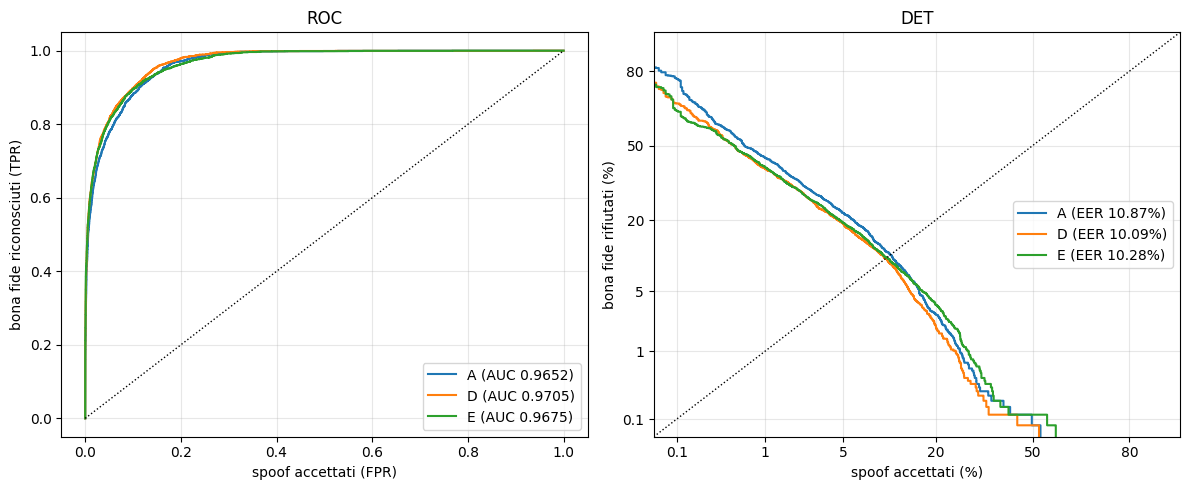

In [9]:
from scipy.stats import norm
_trapz = getattr(np, "trapezoid", None) or np.trapz      # compatibilità tra versioni di NumPy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for k, v in enumerate(VARIANTS):
    s_ = avg[v].astype(np.float64)
    frr, far, _ = asv_metrics.compute_det_curve(s_[Y_DEV == 1], s_[Y_DEV == 0])
    fpr, tpr = far[::-1], (1 - frr)[::-1]                    # ordine crescente di FPR
    auc_off_curve = float(_trapz(tpr, fpr))
    auc_sk = roc_auc_score(Y_DEV, s_)
    assert abs(auc_off_curve - auc_sk) < 1e-3, (auc_off_curve, auc_sk)
    eer = compute_eer(Y_DEV, s_)
    axes[0].plot(fpr, tpr, color=f"C{k}", label=f"{v} (AUC {auc_sk:.4f})")
    fa, fr = np.clip(far, 1e-4, 1 - 1e-4), np.clip(frr, 1e-4, 1 - 1e-4)
    axes[1].plot(norm.ppf(fa), norm.ppf(fr), color=f"C{k}", label=f"{v} (EER {100 * eer:.2f}%)")
axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[0].set_xlabel("spoof accettati (FPR)"); axes[0].set_ylabel("bona fide riconosciuti (TPR)"); axes[0].set_title("ROC")
ticks = np.array([0.001, 0.01, 0.05, 0.2, 0.5, 0.8])
for setter in (axes[1].set_xticks, axes[1].set_yticks):
    setter(norm.ppf(ticks))
axes[1].set_xticklabels([f"{100 * t:g}" for t in ticks]); axes[1].set_yticklabels([f"{100 * t:g}" for t in ticks])
lim = norm.ppf([0.0005, 0.9])
axes[1].plot(lim, lim, "k:", lw=1); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("spoof accettati (%)"); axes[1].set_ylabel("bona fide rifiutati (%)"); axes[1].set_title("DET")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "roc_det.png", dpi=120); plt.show()

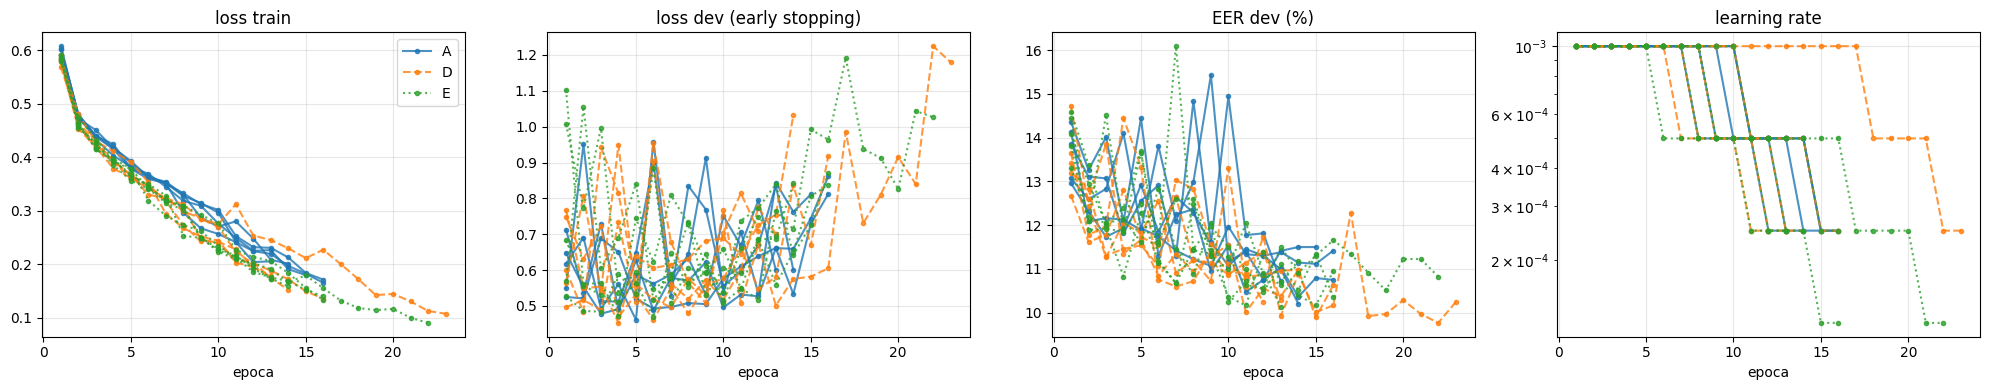

Output: ['__pycache__', 'attention_A_seed0.npz', 'attention_A_seed1.npz', 'attention_A_seed2.npz', 'attention_A_seed3.npz', 'attention_A_seed4.npz', 'attention_D_seed0.npz', 'attention_D_seed1.npz', 'attention_D_seed2.npz', 'attention_D_seed3.npz', 'attention_D_seed4.npz', 'attention_E_seed0.npz', 'attention_E_seed1.npz', 'attention_E_seed2.npz', 'attention_E_seed3.npz', 'attention_E_seed4.npz', 'comparisons.csv', 'curves.png', 'eval_metrics.py', 'history.csv', 'model_A_seed0.pt', 'model_A_seed1.pt', 'model_A_seed2.pt', 'model_A_seed3.pt', 'model_A_seed4.pt', 'model_D_seed0.pt', 'model_D_seed1.pt', 'model_D_seed2.pt', 'model_D_seed3.pt', 'model_D_seed4.pt', 'model_E_seed0.pt', 'model_E_seed1.pt', 'model_E_seed2.pt', 'model_E_seed3.pt', 'model_E_seed4.pt', 'preproc_A.json', 'preproc_D.json', 'preproc_E.json', 'results.csv', 'roc_det.png', 'scores_A_seed0.npy', 'scores_A_seed1.npy', 'scores_A_seed2.npy', 'scores_A_seed3.npy', 'scores_A_seed4.npy', 'scores_D_seed0.npy', 'scores_D_seed1.np

In [10]:
h = pd.read_csv(HIST)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for (v, s), d in h.groupby(["variant", "seed"]):
    k = VARIANTS.index(v)
    kw = dict(color=f"C{k}", ls=["-", "--", ":"][k], alpha=0.8, label=f"{v}" if s == SEEDS[0] else None, marker=".")
    axes[0].plot(d["epoch"], d["train_loss"], **kw)
    axes[1].plot(d["epoch"], d["dev_loss"], **kw)
    axes[2].plot(d["epoch"], 100 * d["dev_eer"], **kw)
    axes[3].plot(d["epoch"], d["lr"], **kw)
axes[3].set_yscale("log")
for ax, t in zip(axes, ["loss train", "loss dev (early stopping)", "EER dev (%)", "learning rate"]):
    ax.set_title(t); ax.set_xlabel("epoca"); ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "curves.png", dpi=120); plt.show()

summary_out = {"config": CONFIG, "variants": {"A": "8 feature", "D": "8 feature + delta", "E": "8 feature + delta + delta-delta"},
               "dynamic_features": "delta_k = f_k - f_(k-1); deltadelta_k = delta_k - delta_(k-1) (Aalto, Introduction to Speech "
                                   "Processing); 0 se una delle finestre coinvolte e' senza voce",
               "eer_dev_%": summary.round(3).reset_index().to_dict("records"),
               "eer_per_seed_%": per_seed.round(3).reset_index().to_dict("records"),
               "comparisons": comparisons.round(4).astype({"seed": str}).to_dict("records"),
               "auc_dev": {v: roc_auc_score(Y_DEV, avg[v]) for v in VARIANTS},
               "auc_function": "sklearn.metrics.roc_auc_score (metrica non ASVspoof, complementare)", "eer_per_attack_%": per_attack.reset_index().to_dict("records"),
               "lead_silence_spearman": diag.reset_index().to_dict("records"),
               "training": {"max_epochs": MAX_EPOCHS, "patience": PATIENCE, "batch_size": BATCH_SIZE, "lr_initial": LR,
                            "lr_scheduler": {"type": "ReduceLROnPlateau (loss dev)", "factor": LR_FACTOR, "patience": LR_PATIENCE},
                            "dropout": DROPOUT, "clip_pct": CLIP_PCT, "pos_weight": POS_W,
                            "early_stopping": "loss BCE pesata sul dev", "device": DEVICE},
               "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256}}
_ = (OUT_DIR / "summary.json").write_text(json.dumps(summary_out, indent=2, default=float))
print("Output:", sorted(p.name for p in OUT_DIR.iterdir()))